In [1]:
import pandas as pd

# Load the already-saved Titanic dataset
df = pd.read_csv("titanic.csv")

print("Titanic CSV loaded successfully.")
print("Shape:", df.shape)

Titanic CSV loaded successfully.
Shape: (891, 15)


In [2]:
# Check survival class balance before train/test split

class_counts = df["survived"].value_counts().sort_index()
class_percentages = df["survived"].value_counts(normalize=True).sort_index() * 100

class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

class_balance.index = ["Not Survived (0)", "Survived (1)"]

print("=== SURVIVAL CLASS BALANCE ===")
display(class_balance)

=== SURVIVAL CLASS BALANCE ===


,Count,Percentage
Not Survived (0),549,61.62
Survived (1),342,38.38


In [3]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=["survived"])
y = df["survived"]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== TRAIN/TEST SPLIT ===")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\n=== TRAINING CLASS BALANCE ===")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\n=== TEST CLASS BALANCE ===")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

=== TRAIN/TEST SPLIT ===
X_train shape: (712, 14)
X_test shape : (179, 14)
y_train shape: (712,)
y_test shape : (179,)

=== TRAINING CLASS BALANCE ===
survived
0    61.66
1    38.34
Name: proportion, dtype: float64

=== TEST CLASS BALANCE ===
survived
0    61.45
1    38.55
Name: proportion, dtype: float64


## Stratified Train/Test Split

The target variable `survived` contains 549 non-survivors (61.62%) and 342 survivors (38.38%). Because the target classes are not evenly distributed, a stratified train/test split was used to preserve approximately the same class proportions in both subsets.

An 80/20 split with `random_state=42` and `stratify=y` produced 712 training observations and 179 test observations. The training set contains 61.66% non-survivors and 38.34% survivors, while the test set contains 61.45% non-survivors and 38.55% survivors. This confirms that stratification preserved the observed target-class distribution while keeping the test set separate from training data.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify feature types
numeric_features = [
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked",
    "class",
    "who",
    "adult_male",
    "alone"
]

# Numeric preprocessing:
# median imputation + standardization
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing:
# most-frequent imputation + one-hot encoding
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Preprocessing pipeline created successfully.
Numeric features: ['age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked', 'class', 'who', 'adult_male', 'alone']


In [5]:
# Fit preprocessing ONLY on the training data

preprocessor.fit(X_train, y_train)

# Transform training and test data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing fitted successfully on training data only.")
print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Same number of processed features:",
      X_train_processed.shape[1] == X_test_processed.shape[1])

Preprocessing fitted successfully on training data only.
Processed training shape: (712, 19)
Processed test shape: (179, 19)
Same number of processed features: True


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Define the three classifiers
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train all three models on the same training data
logistic_model.fit(X_train_processed, y_train)
decision_tree_model.fit(X_train_processed, y_train)
random_forest_model.fit(X_train_processed, y_train)

print("=== CLASSIFIER TRAINING COMPLETE ===")
print("Logistic Regression: trained")
print("Decision Tree: trained")
print("Random Forest: trained")

=== CLASSIFIER TRAINING COMPLETE ===
Logistic Regression: trained
Decision Tree: trained
Random Forest: trained


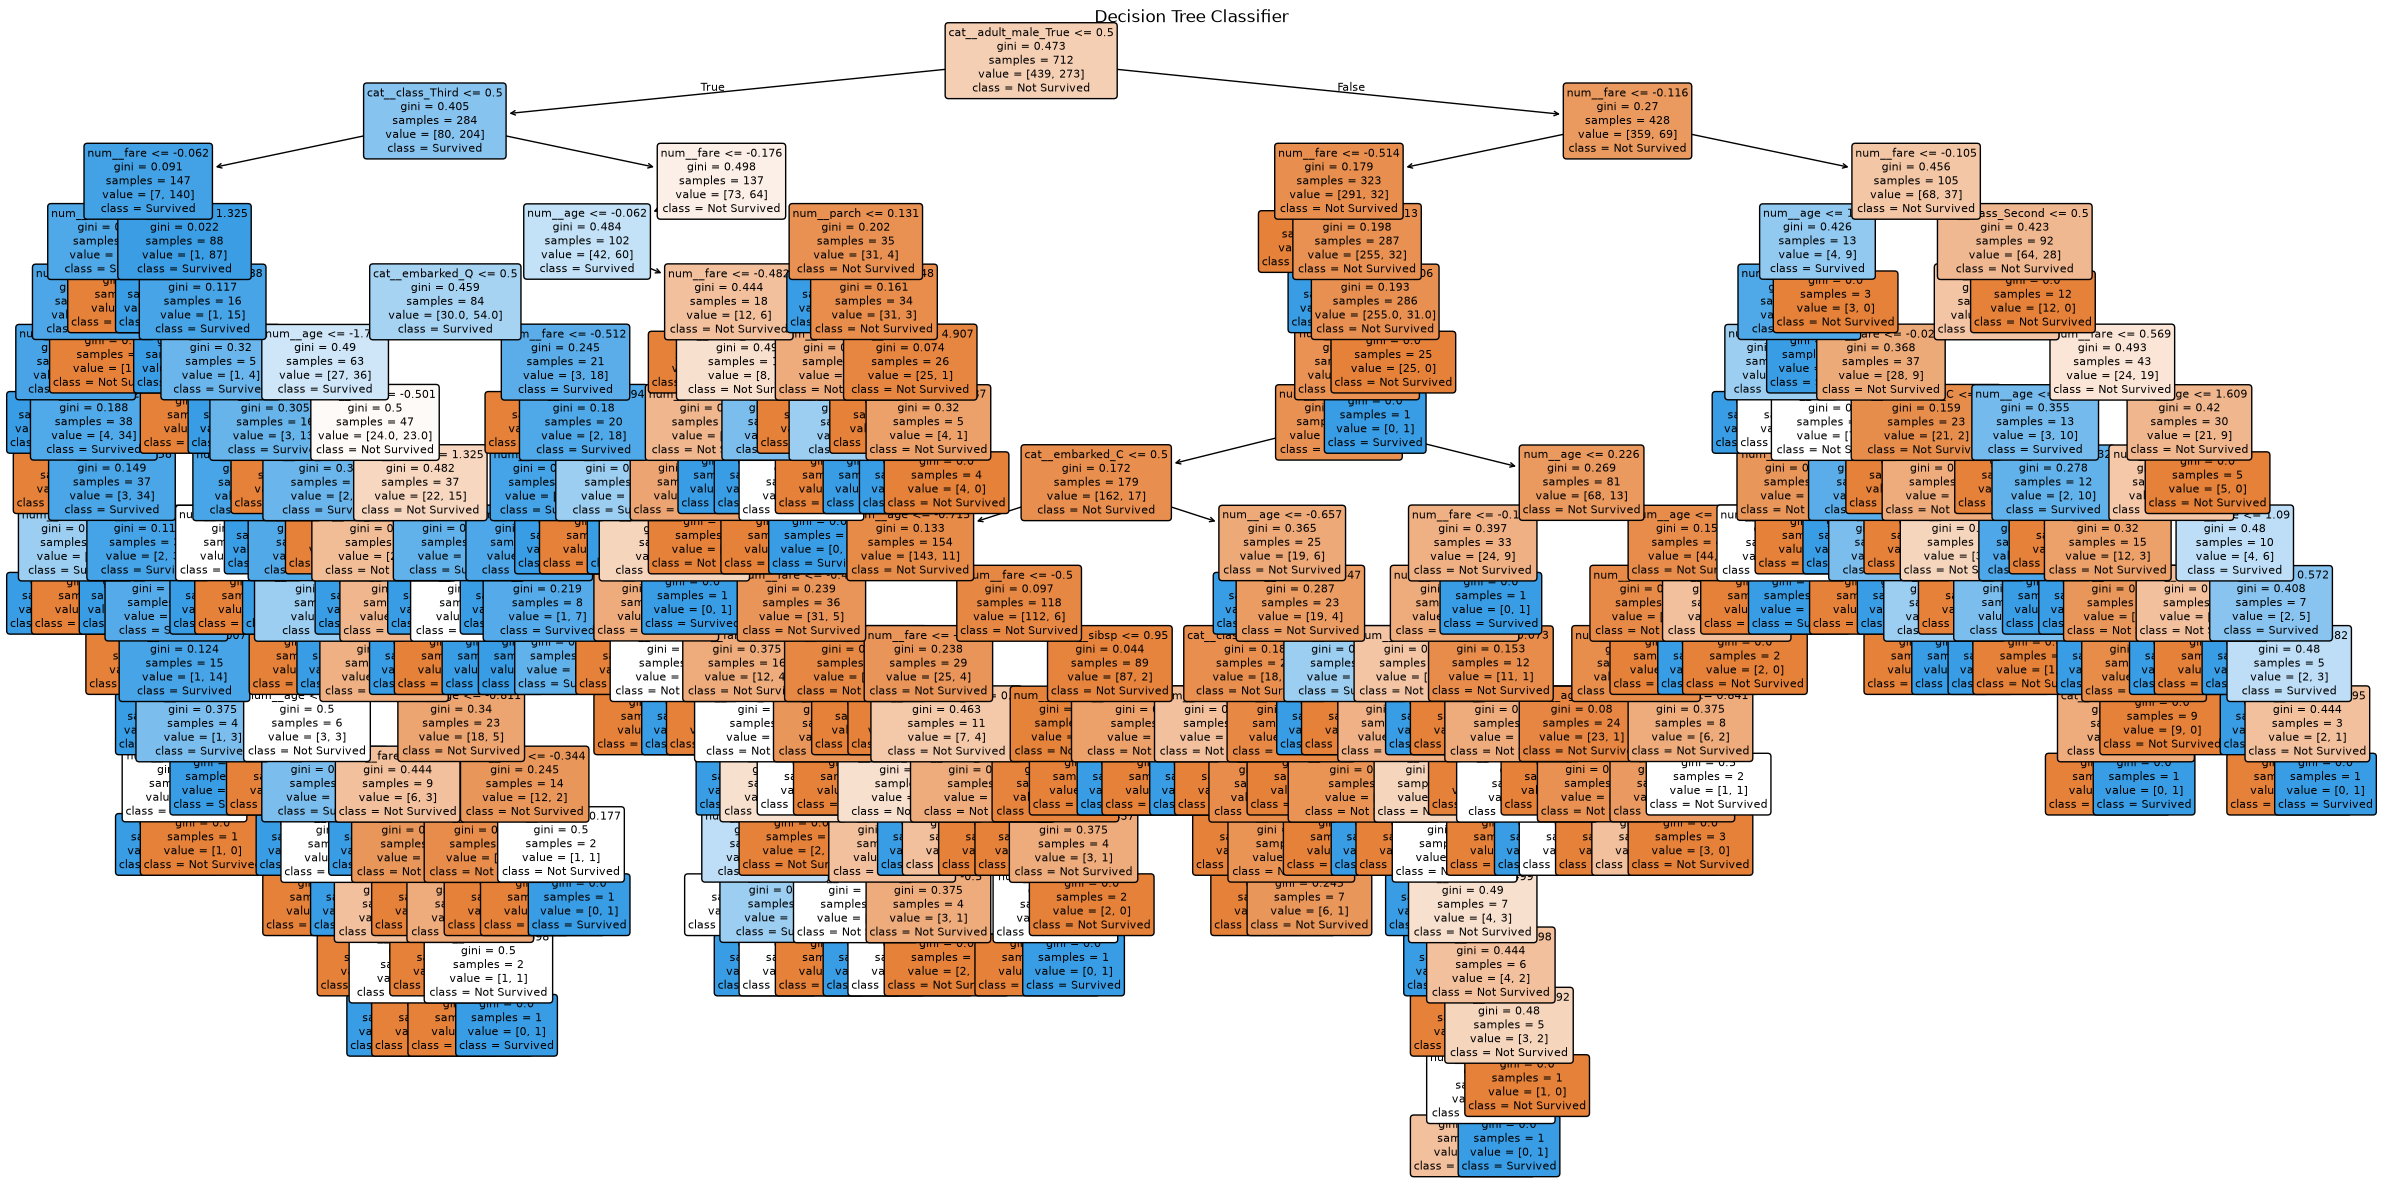

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

comparison_df = pd.DataFrame(results)

print("\n=== CLASSIFIER COMPARISON ===")
display(comparison_df.round(4))


=== Logistic Regression ===
Confusion Matrix:
[[98 12]
 [17 52]]

=== Decision Tree ===
Confusion Matrix:
[[92 18]
 [18 51]]

=== Random Forest ===
Confusion Matrix:
[[97 13]
 [21 48]]

=== CLASSIFIER COMPARISON ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8380,0.8125,0.7536,0.7820,0.8685
1,Decision Tree,0.7989,0.7391,0.7391,0.7391,0.7769
2,Random Forest,0.8101,0.7869,0.6957,0.7385,0.8372


In [9]:
from imblearn.over_sampling import SMOTE

# --------------------------------------------------
# 1. Baseline Logistic Regression
# --------------------------------------------------

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train)

baseline_pred = baseline_model.predict(X_test_processed)

# --------------------------------------------------
# 2. Logistic Regression with class_weight='balanced'
# --------------------------------------------------

balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(X_train_processed, y_train)

balanced_pred = balanced_model.predict(X_test_processed)

# --------------------------------------------------
# 3. Logistic Regression with SMOTE
# --------------------------------------------------

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test_processed)

# --------------------------------------------------
# Compare results
# --------------------------------------------------

imbalance_results = pd.DataFrame([
    {
        "Method": "Baseline",
        "Precision": precision_score(y_test, baseline_pred),
        "Recall": recall_score(y_test, baseline_pred),
        "F1": f1_score(y_test, baseline_pred)
    },
    {
        "Method": "class_weight='balanced'",
        "Precision": precision_score(y_test, balanced_pred),
        "Recall": recall_score(y_test, balanced_pred),
        "F1": f1_score(y_test, balanced_pred)
    },
    {
        "Method": "SMOTE",
        "Precision": precision_score(y_test, smote_pred),
        "Recall": recall_score(y_test, smote_pred),
        "F1": f1_score(y_test, smote_pred)
    }
])

print("=== CLASS IMBALANCE COMPARISON ===")
display(imbalance_results.round(4))

print("\nOriginal training class counts:")
print(y_train.value_counts())

print("\nSMOTE training class counts:")
print(pd.Series(y_train_smote).value_counts())

=== CLASS IMBALANCE COMPARISON ===


,Method,Precision,Recall,F1
0,Baseline,0.8125,0.7536,0.7820
1,class_weight='balanced',0.7671,0.8116,0.7887
2,SMOTE,0.7632,0.8406,0.8000



Original training class counts:
survived
0    439
1    273
Name: count, dtype: int64

SMOTE training class counts:
survived
1    439
0    439
Name: count, dtype: int64


## Class Imbalance Analysis

The training data contained 439 non-survivors and 273 survivors, showing a moderate class imbalance. Three Logistic Regression approaches were compared: the baseline model, class weighting, and SMOTE applied only to the training data.

The baseline achieved a precision of 0.8125, recall of 0.7536, and F1-score of 0.7820. Using `class_weight="balanced"` increased recall to 0.8116 but reduced precision to 0.7671, resulting in an F1-score of 0.7887.

SMOTE produced the highest recall of 0.8406 and the highest F1-score of 0.8000, while precision decreased to 0.7632. Therefore, in this experiment, SMOTE provided the strongest balance between precision and recall according to F1-score, while the baseline provided the highest precision.

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Random Forest with OOB scoring enabled
rf_grid_model = RandomForestClassifier(
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"]
}

# GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=rf_grid_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

# IMPORTANT: fit only on the training data
rf_grid_search.fit(X_train_processed, y_train)

# Best model
best_rf_model = rf_grid_search.best_estimator_

print("=== RANDOM FOREST GRID SEARCH ===")
print("Best parameters:")
print(rf_grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(round(rf_grid_search.best_score_, 4))

print("\nBest Random Forest OOB score:")
print(round(best_rf_model.oob_score_, 4))

=== RANDOM FOREST GRID SEARCH ===
Best parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}

Best cross-validation F1-score:
0.7494

Best Random Forest OOB score:
0.8272


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --------------------------------------------------
# Prepare data for fare regression
# --------------------------------------------------

regression_df = df.copy()

# Target
y_reg = regression_df["fare"]

# Remove target and columns that should not be used as predictors
X_reg = regression_df.drop(columns=["fare"])

# Use the same train/test indices as the classification split
X_reg_train = X_reg.loc[X_train.index]
X_reg_test = X_reg.loc[X_test.index]

y_reg_train = y_reg.loc[X_train.index]
y_reg_test = y_reg.loc[X_test.index]

# --------------------------------------------------
# Preprocessing for regression
# --------------------------------------------------

reg_numeric_features = [
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked",
    "class",
    "who",
    "adult_male",
    "alone"
]

reg_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

reg_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", reg_numeric_transformer, reg_numeric_features),
        ("cat", reg_categorical_transformer, reg_categorical_features)
    ]
)

# --------------------------------------------------
# Fit preprocessing ONLY on regression training data
# --------------------------------------------------

X_reg_train_processed = reg_preprocessor.fit_transform(X_reg_train)
X_reg_test_processed = reg_preprocessor.transform(X_reg_test)

# --------------------------------------------------
# Train multivariate linear regression
# --------------------------------------------------

linear_regression = LinearRegression()

linear_regression.fit(
    X_reg_train_processed,
    y_reg_train
)

# Predictions
y_reg_pred = linear_regression.predict(X_reg_test_processed)

# --------------------------------------------------
# Regression metrics
# --------------------------------------------------

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = X_reg_test_processed.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("=== LINEAR REGRESSION RESULTS ===")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))

=== LINEAR REGRESSION RESULTS ===
MAE: 16.464
RMSE: 41.8471
R²: 0.4353
Adjusted R²: 0.3718


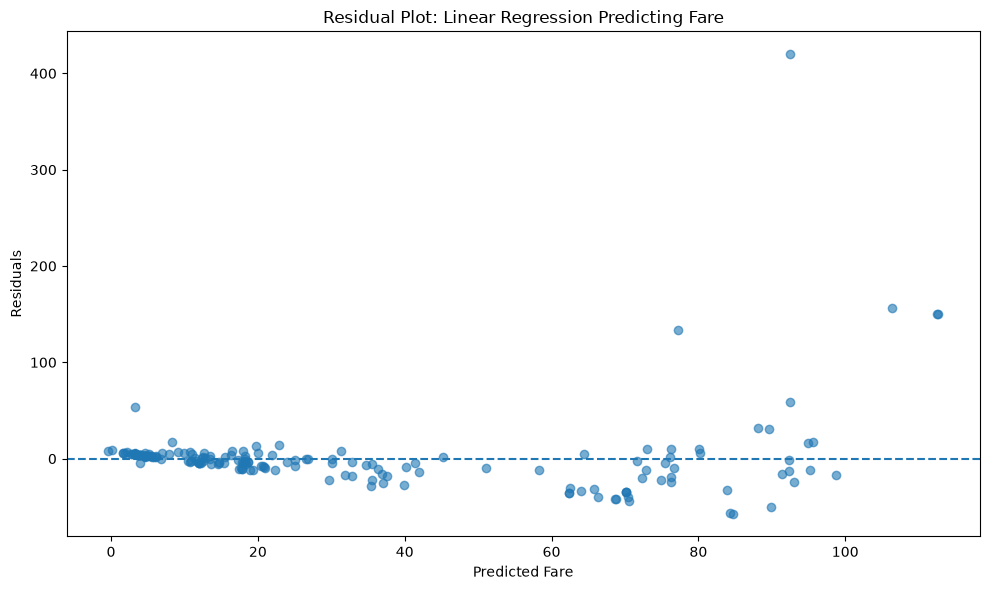

In [12]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_reg_test - y_reg_pred

# Residual plot
plt.figure(figsize=(10, 6))

plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression Predicting Fare")

plt.tight_layout()
plt.show()

## Residual Analysis and Heteroscedasticity

The residual plot shows that the residual spread is not constant across the range of predicted fare values. At lower predicted fares, the residuals are relatively concentrated around zero, while at higher predicted fares the residuals show substantially greater dispersion and several large positive values.

This widening spread indicates evidence of **heteroscedasticity**, meaning that the variance of the regression errors changes with the predicted fare. Therefore, the constant-variance assumption of ordinary linear regression is not fully satisfied for this model. The presence of several extreme residuals also suggests that high-fare observations have a strong influence on prediction errors.

In [13]:
# ==================================================
# FINAL MODEL COMPARISON
# ==================================================

# Classifier comparison
final_classifier_table = comparison_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
].copy()

print("=== FINAL CLASSIFIER COMPARISON ===")
display(final_classifier_table.round(4))


# Regression comparison
final_regression_table = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Adjusted R²"
    ],
    "Linear Regression": [
        mae,
        rmse,
        r2,
        adjusted_r2
    ]
})

print("\n=== FINAL REGRESSION RESULTS ===")
display(final_regression_table.round(4))

=== FINAL CLASSIFIER COMPARISON ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8380,0.8125,0.7536,0.7820,0.8685
1,Decision Tree,0.7989,0.7391,0.7391,0.7391,0.7769
2,Random Forest,0.8101,0.7869,0.6957,0.7385,0.8372



=== FINAL REGRESSION RESULTS ===


,Metric,Linear Regression
0,MAE,16.4640
1,RMSE,41.8471
2,R²,0.4353
3,Adjusted R²,0.3718


## Final Model Comparison and Recommendation

The three classification models produced different performance across accuracy, precision, recall, F1-score, and ROC-AUC. Logistic Regression achieved an accuracy of 0.8380, precision of 0.8125, recall of 0.7536, F1-score of 0.7820, and ROC-AUC of 0.8685. Decision Tree achieved an accuracy of 0.7989, precision of 0.7391, recall of 0.7391, F1-score of 0.7391, and ROC-AUC of 0.7769. Random Forest achieved an accuracy of 0.8101, precision of 0.7869, recall of 0.6957, F1-score of 0.7385, and ROC-AUC of 0.8372.

Based on these observed test-set metrics, Logistic Regression provides the strongest overall classification performance in this experiment, particularly with the highest accuracy and ROC-AUC among the three models. The class-imbalance analysis also showed that SMOTE increased recall to 0.8406 and F1-score to 0.8000, while reducing precision to 0.7632. For the regression task, Linear Regression produced an MAE of 16.4640, RMSE of 41.8471, R² of 0.4353, and adjusted R² of 0.3718, indicating that the model explains a moderate portion of fare variation and that the residual analysis shows evidence of heteroscedasticity.

In [17]:
# ============================================
# SAVE COMPLETE BEST MODEL PIPELINE
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import joblib
import os

# Create complete pipeline:
# Raw data -> preprocessing -> Logistic Regression
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the complete pipeline on RAW training data
full_pipeline.fit(X_train, y_train)

# Create output directory
os.makedirs("outputs", exist_ok=True)

# Save complete pipeline
pipeline_path = "outputs/best_titanic_pipeline.joblib"
joblib.dump(full_pipeline, pipeline_path)

print("Complete pipeline saved successfully.")
print("Pipeline path:", pipeline_path)
print("Pipeline steps:", full_pipeline.named_steps)


Complete pipeline saved successfully.
Pipeline path: outputs/best_titanic_pipeline.joblib
Pipeline steps: {'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'sibsp', 'parch', 'fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'embarked', 'class', 'who',
                                  'adult_male', 'alone'])]), 'model': LogisticRegression(max_iter=1000, random_state=42)}


In [18]:
# ============================================
# RELOAD PIPELINE AND TEST ON RAW NEW INPUT
# ============================================

import joblib
import pandas as pd

# Reload the saved complete pipeline
loaded_pipeline = joblib.load("outputs/best_titanic_pipeline.joblib")

# Create one raw passenger record
new_passenger = pd.DataFrame({
    "pclass": [3],
    "sex": ["male"],
    "age": [25],
    "sibsp": [0],
    "parch": [0],
    "fare": [10.0],
    "embarked": ["S"],
    "class": ["Third"],
    "who": ["man"],
    "adult_male": [True],
    "deck": [None],
    "embark_town": ["Southampton"],
    "alive": ["no"],
    "alone": [True]
})

# Make prediction using RAW input
prediction = loaded_pipeline.predict(new_passenger)

print("Pipeline reloaded successfully.")
print("Prediction for new raw passenger:", prediction[0])

if prediction[0] == 1:
    print("Predicted outcome: Survived")
else:
    print("Predicted outcome: Not Survived")

Pipeline reloaded successfully.
Prediction for new raw passenger: 0
Predicted outcome: Not Survived
